In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0,No Anomaly


### K-Means

In [4]:
dataframe_data = dataframe.drop(columns=["description"])
dataframe_data

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0


In [5]:
kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

,n_clusters,14
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [6]:
combined = zip(dataframe.anomaly.values, dataframe.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

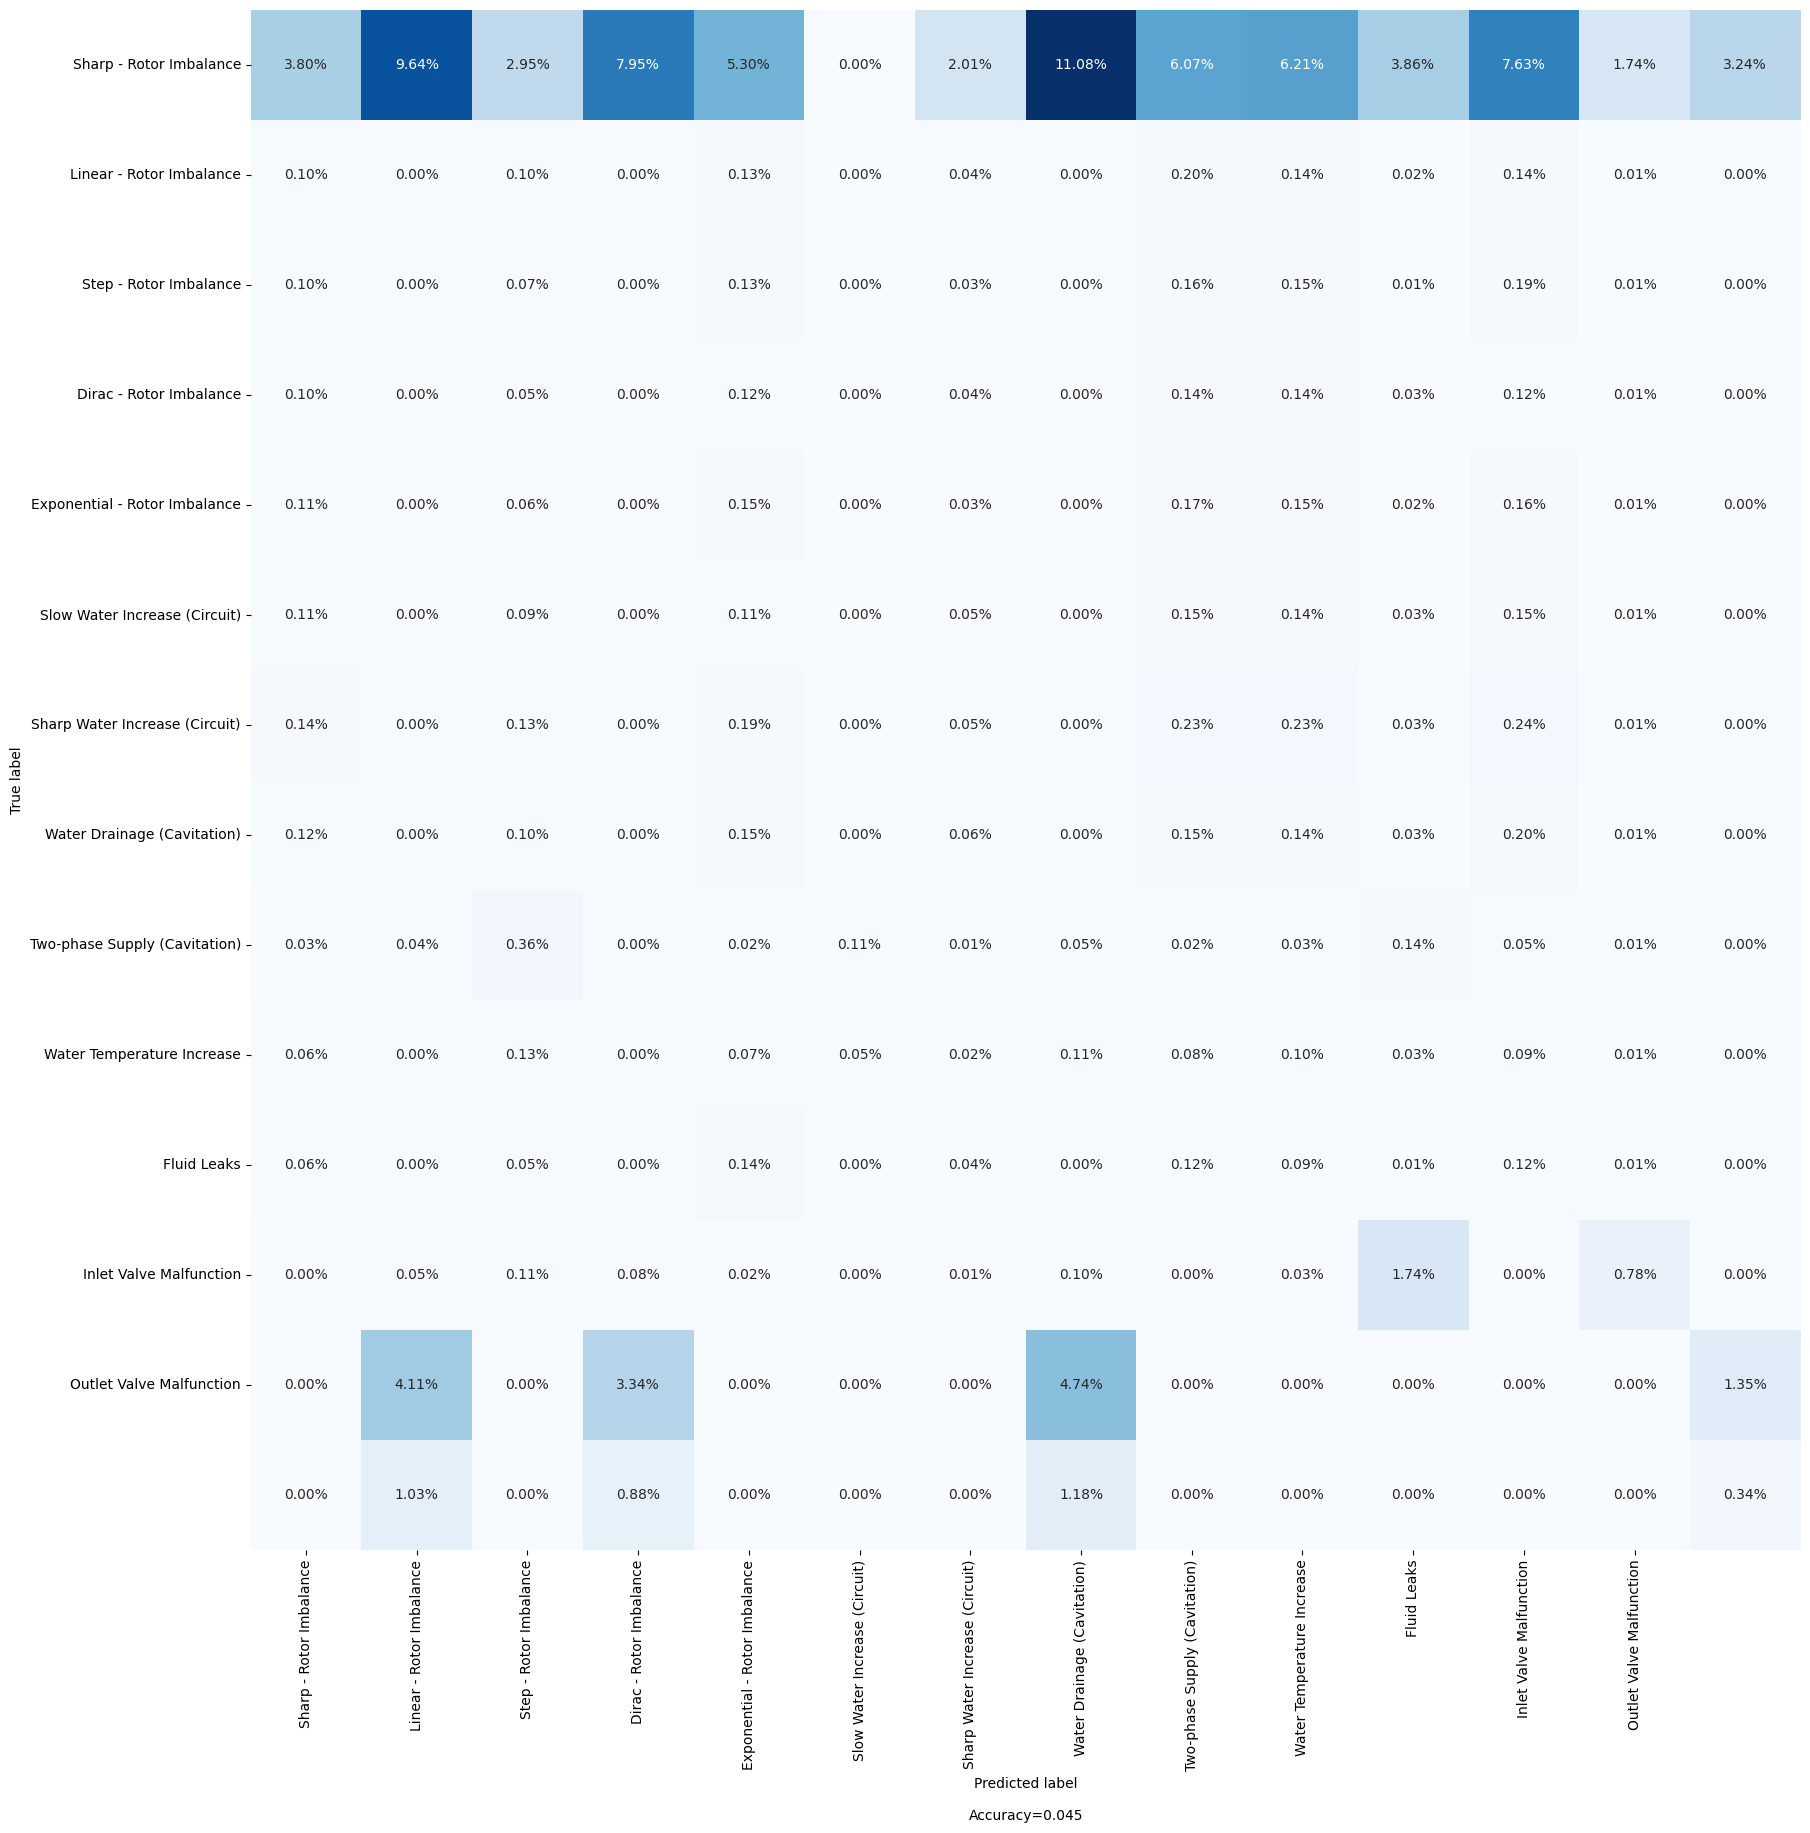

In [7]:
plot.make_confusion_matrix(
    confusion_matrix(dataframe_data.anomaly.values, kmeans_custom.labels_),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

### Isolation Forest

In [8]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

X_train, X_test, y_train, y_test = train_test_split(
                                                        dataframe_X.values, 
                                                        dataframe_y.values.ravel(), 
                                                        test_size=0.3, 
                                                        random_state=SEED, 
                                                        stratify=dataframe_y.values.ravel()
)
dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [9]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [10]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 4385 anomalies in test set.


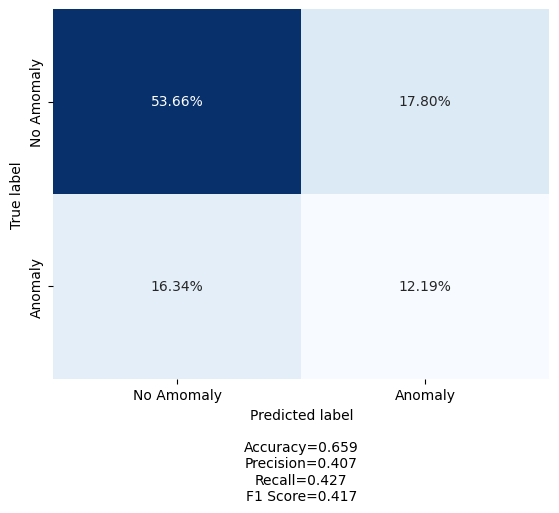

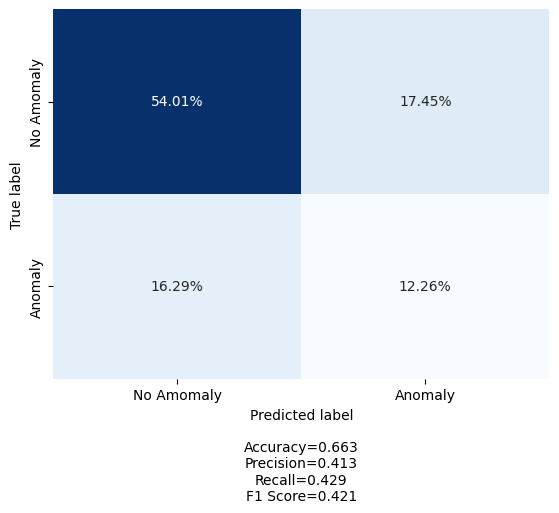

In [11]:
y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, train_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [12]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [13]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 133 anomalies in test set.


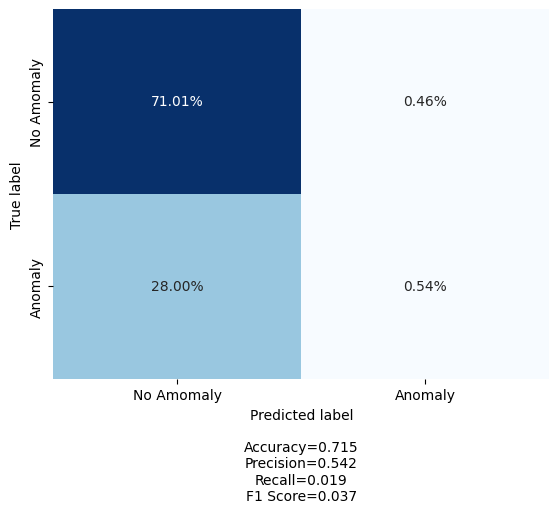

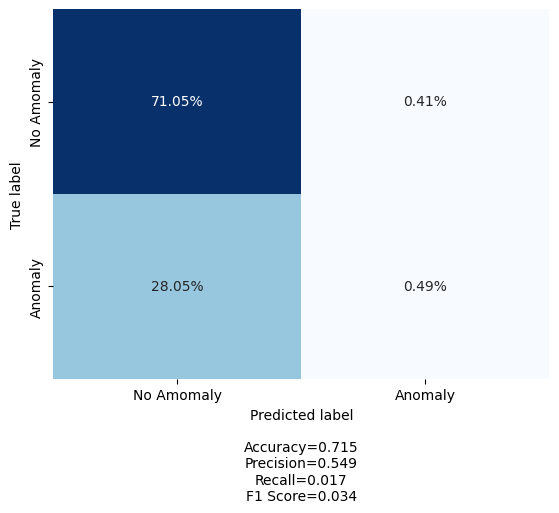

In [14]:
y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, train_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [15]:
# dataframe_no_anomaly = dataframe[dataframe["anomaly"] == 0]
# dataframe_no_anomaly.drop(columns=["anomaly", "description"], inplace=True)

In [16]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     if i[0] == 0: continue
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

In [17]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
#     if idx == 0: continue  # Skip the normal class (0)
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [18]:
# for idx, (center, distance) in enumerate(zip(initial_centers, distances), 1):
#     tmp = dataframe_no_anomaly.apply(lambda row: np.linalg.norm(row - center), axis=1)
#     per = np.where(tmp < distance, 1, 0).sum() / tmp.shape[0] * 100
#     print(f"{idx}, {anomaly_ids[idx]}, Percentage within distance: {per:.2f}%")

In [19]:
# dataframe_all = dataframe.drop(columns=["anomaly", "description"])
# dataframe_all.shape

In [20]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

# for idx, name in anomaly_ids.items():
#     print(f"{idx}, {name}") 

In [21]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [22]:
# for idx1, name in anomaly_ids.items():
#     tmp = dataframe[dataframe["anomaly"] == idx]
#     tmp.drop(columns=["anomaly", "description"], inplace=True)

#     for idx2, (center, distance) in enumerate(zip(initial_centers, distances)):
#         tmp2 = tmp.apply(lambda row: np.linalg.norm(row - center), axis=1)
#         per = np.where(tmp2 < distance, 1, 0).sum() / tmp2.shape[0] * 100
#         print(f"{anomaly_ids[idx1]}, {anomaly_ids[idx2]}, Percentage within distance: {per:.2f}%")